# **Quantum GNN for Higgs Tracking**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Importing Modules and Libraries

In [ ]:
!pip install torch-Geometric
!pip install uproot

In [ ]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
import torch
if not torch.distributed.is_initialized():
    torch.set_num_threads(1)
    if hasattr(torch, 'set_num_interop_threads'):
        try:
            torch.set_num_interop_threads(1)
            print("Interop threads set to 1 successfully.")
        except RuntimeError:
            print("Interop threads were already initialized.")
import shutil
import time
import json
import pickle
import datetime
import warnings
import gc
import numpy as np
import pandas as pd
import requests
import torch.nn as nn
import torch.nn.functional as F
import uproot
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from mpl_toolkits.mplot3d import Axes3D
from plotly.subplots import make_subplots
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MessagePassing
from tqdm import tqdm

warnings.filterwarnings('ignore')


Interop threads were already initialized.


# Initializing the seed

In [ ]:
torch.manual_seed(42)
np.random.seed(42)

# Setting up google drive

In [ ]:
class GoogleDriveManager:
    """Manages Google Drive storage for Higgs Track Filter project"""

    def __init__(self):
        self.project_name = "Higgs_Track_Filter"
        self.drive_base = None
        self.local_base = None
        self.is_colab = False


        try:
            from google.colab import drive
            self.is_colab = True
            drive.mount('/content/drive')
            self.drive_base = f'/content/drive/MyDrive/{self.project_name}'
            print(f"✓ Running in Google Colab - Drive mounted")
        except:
            self.is_colab = False
            self.local_base = f'./{self.project_name}'
            print(f"✓ Running locally - using local storage")


        self.setup_directories()

    def setup_directories(self):
        """Create all necessary directories"""
        base_path = self.drive_base if self.is_colab else self.local_base

        self.directories = {
            'root': base_path,
            'data': os.path.join(base_path, 'data'),
            'models': os.path.join(base_path, 'models'),
            'results': os.path.join(base_path, 'results'),
            'plots': os.path.join(base_path, 'plots'),
            'visualizations': os.path.join(base_path, 'visualizations'),
            'checkpoints': os.path.join(base_path, 'checkpoints'),
            'logs': os.path.join(base_path, 'logs'),
            'cern_data': os.path.join(base_path, 'cern_data'),
            'processed': os.path.join(base_path, 'processed_data')
        }

        for dir_path in self.directories.values():
            os.makedirs(dir_path, exist_ok=True)

        print(f"✓ Project directories created at: {base_path}")

    def get_path(self, dir_type, filename=None):
        if dir_type not in self.directories:
            raise ValueError(f"Unknown directory type: {dir_type}")

        path = self.directories[dir_type]
        if filename:
            path = os.path.join(path, filename)

        return path

    def save_dataframe(self, df, filename, dir_type='data'):
        """Save dataframe to Google Drive"""
        path = self.get_path(dir_type, filename)
        df.to_parquet(path, index=False)
        print(f"✓ Saved {filename} to {path}")
        return path

    def save_model(self, model, filename, dir_type='models'):
        """Save model to Google Drive"""
        path = self.get_path(dir_type, filename)
        torch.save(model.state_dict(), path)
        print(f"✓ Saved model to {path}")
        return path

    def save_checkpoint(self, checkpoint, filename):
        """Save training checkpoint"""
        path = self.get_path('checkpoints', filename)
        torch.save(checkpoint, path)
        print(f"✓ Saved checkpoint to {path}")
        return path

    def save_plot(self, fig, filename):
        """Save matplotlib figure"""
        path = self.get_path('plots', filename)
        fig.savefig(path, dpi=150, bbox_inches='tight')
        print(f"✓ Saved plot to {path}")
        plt.close(fig)
        return path

    def save_html(self, fig, filename):
        """Save plotly figure as HTML"""
        path = self.get_path('visualizations', filename)
        fig.write_html(path)
        print(f"✓ Saved interactive visualization to {path}")
        return path

    def save_json(self, data, filename):
        """Save JSON data"""
        path = self.get_path('results', filename)
        with open(path, 'w') as f:
            json.dump(data, f, indent=2)
        print(f"✓ Saved JSON to {path}")
        return path

    def save_pickle(self, data, filename, dir_type='processed'):
        """Save pickle file"""
        path = self.get_path(dir_type, filename)
        with open(path, 'wb') as f:
            pickle.dump(data, f)
        print(f"✓ Saved pickle to {path}")
        return path

    def load_model(self, model, filename, dir_type='models'):
        """Load model from Google Drive"""
        path = self.get_path(dir_type, filename)
        if os.path.exists(path):
            model.load_state_dict(torch.load(path, map_location='cpu'))
            print(f"✓ Loaded model from {path}")
            return True
        print(f"⚠ Model not found: {path}")
        return False

    def list_files(self, dir_type):
        """List files in directory"""
        path = self.get_path(dir_type)
        return os.listdir(path)


# Data Generation

In [ ]:
class CERNOpenDataDownloader:
    """Download data directly from CERN Open Data portal"""

    def __init__(self, cache_dir='./cern_data'):
        self.cache_dir = cache_dir
        os.makedirs(cache_dir, exist_ok=True)

        # CERN Open Data endpoints
        self.datasets = {
            'higgs_4l': {
                'url': 'http://opendata.cern.ch/record/12351/files/Higgs4L_2012.parquet',
                'description': 'Higgs to 4 leptons (2012)',
                'size_mb': 45
            },
            'higgs_tautau': {
                'url': 'http://opendata.cern.ch/record/12352/files/HiggsTauTau_2012.parquet',
                'description': 'Higgs to tau tau (2012)',
                'size_mb': 38
            },
            'cms_tracks': {
                'url': 'http://opendata.cern.ch/record/12350/files/CMS_Tracking_2012.parquet',
                'description': 'CMS tracking data (2012)',
                'size_mb': 52
            }
        }

    def download_dataset(self, dataset_name):
        """Download dataset from CERN Open Data"""
        if dataset_name not in self.datasets:
            print(f"Dataset {dataset_name} not found. Available: {list(self.datasets.keys())}")
            return None

        dataset_info = self.datasets[dataset_name]
        url = dataset_info['url']
        filename = os.path.join(self.cache_dir, f"{dataset_name}.parquet")

        if os.path.exists(filename):
            print(f"✓ Dataset already exists: {filename}")
            return filename

        print(f"Downloading {dataset_name} from CERN Open Data...")
        print(f"URL: {url}")
        print(f"Size: ~{dataset_info['size_mb']} MB")

        try:
            response = requests.get(url, stream=True, timeout=60)
            response.raise_for_status()

            total_size = int(response.headers.get('content-length', 0))
            block_size = 8192

            with open(filename, 'wb') as f:
                with tqdm(total=total_size, unit='B', unit_scale=True, desc=dataset_name) as pbar:
                    for chunk in response.iter_content(chunk_size=block_size):
                        if chunk:
                            f.write(chunk)
                            pbar.update(len(chunk))

            print(f"✓ Downloaded: {filename}")
            return filename

        except Exception as e:
            print(f"Error downloading {dataset_name}: {e}")
            print("Falling back to synthetic data generation...")
            return None

    def _optimize_dataframe(self, df, max_events=None):
        df = df.copy()

        int_cols = df.select_dtypes(include=['int64', 'int32']).columns
        float_cols = df.select_dtypes(include=['float64', 'float32']).columns

        for col in int_cols:
            df[col] = pd.to_numeric(df[col], downcast='integer')
        for col in float_cols:
            df[col] = pd.to_numeric(df[col], downcast='float')

        if max_events is not None and 'event_id' in df.columns:
            keep_ids = df['event_id'].drop_duplicates().iloc[:max_events]
            df = df[df['event_id'].isin(keep_ids)].copy()

        return df.reset_index(drop=True)

    def load_and_process_data(self, dataset_name='higgs_4l', max_events=24):
        """Load and process CERN data"""
        filename = self.download_dataset(dataset_name)

        if filename and os.path.exists(filename):
            try:
                df = pd.read_parquet(filename)
                df = self._optimize_dataframe(df, max_events=max_events)
                print(f"✓ Loaded {len(df)} rows from CERN data")
                return df
            except Exception as e:
                print(f"Error loading {filename}: {e}")

        print("Generating synthetic Higgs data as fallback...")
        return self.generate_synthetic_data(n_events=max_events or 24)

    def generate_synthetic_data(self, n_events=24):
        """Generate synthetic Higgs tracking data"""
        np.random.seed(42)

        tracks = []

        for event_id in range(n_events):
            n_bjets = 2

            for bjet_id in range(n_bjets):
                jet_pt = np.random.uniform(30, 120)
                jet_eta = np.random.uniform(-2.0, 2.0)
                jet_phi = np.random.uniform(-np.pi, np.pi)
                n_tracks = np.random.randint(5, 15)

                for track_id in range(n_tracks):
                    track_pt = jet_pt * np.random.uniform(0.1, 0.8)
                    track_eta = jet_eta + np.random.normal(0, 0.1)
                    track_phi = jet_phi + np.random.normal(0, 0.1)
                    ip = np.random.exponential(0.3)

                    for layer, r in enumerate([30, 60, 90, 120, 200, 400, 600, 800, 1000]):
                        z = r * np.sinh(track_eta)
                        x = r * np.cos(track_phi) + ip * np.cos(track_phi)
                        y = r * np.sin(track_phi) + ip * np.sin(track_phi)

                        x += np.random.normal(0, 0.05)
                        y += np.random.normal(0, 0.05)
                        z += np.random.normal(0, 0.5)

                        significance = min(1.0, track_pt / 100 + ip / 0.5)

                        tracks.append({
                            'event_id': event_id,
                            'track_id': track_id,
                            'bjet_id': bjet_id,
                            'hit_id': layer,
                            'x': x, 'y': y, 'z': z,
                            'r': r,
                            'layer': layer,
                            'pt': track_pt,
                            'eta': track_eta,
                            'phi': track_phi,
                            'ip': ip,
                            'significance': significance,
                            'is_signal': 1
                        })

            n_background = np.random.randint(10, 30)
            for track_id in range(n_background):
                track_pt = np.random.uniform(0.5, 20)
                track_eta = np.random.uniform(-3.0, 3.0)
                track_phi = np.random.uniform(-np.pi, np.pi)
                ip = np.random.exponential(0.05)

                for layer, r in enumerate([30, 60, 90, 120, 200, 400, 600, 800, 1000]):
                    z = r * np.sinh(track_eta)
                    x = r * np.cos(track_phi)
                    y = r * np.sin(track_phi)

                    x += np.random.normal(0, 0.05)
                    y += np.random.normal(0, 0.05)
                    z += np.random.normal(0, 0.5)

                    significance = min(0.3, track_pt / 50)

                    tracks.append({
                        'event_id': event_id,
                        'track_id': track_id + 1000,
                        'bjet_id': -1,
                        'hit_id': layer,
                        'x': x, 'y': y, 'z': z,
                        'r': r,
                        'layer': layer,
                        'pt': track_pt,
                        'eta': track_eta,
                        'phi': track_phi,
                        'ip': ip,
                        'significance': significance,
                        'is_signal': 0
                    })

        df = pd.DataFrame(tracks)
        df = self._optimize_dataframe(df, max_events=n_events)
        print(f"✓ Generated {len(df)} synthetic hits from {n_events} events")
        return df


# Genearting Quantum Model

In [ ]:
class QuantumInspiredLayer(nn.Module):
    """Quantum-inspired neural layer with vectorized entanglement simulation"""

    def __init__(self, n_qubits=4, n_layers=2, input_dim=6):
        super().__init__()
        self.n_qubits = n_qubits
        self.n_layers = n_layers

        self.pre_net = nn.Sequential(
            nn.Linear(input_dim, n_qubits),
            nn.Tanh()
        )

        self.theta = nn.Parameter(torch.randn(n_layers, n_qubits, 3))

        self.post_net = nn.Sequential(
            nn.Linear(n_qubits, n_qubits),
            nn.ReLU()
        )

    def forward(self, x):
        state = torch.tanh(self.pre_net(x))

        for layer in range(self.n_layers):
            layer_theta = self.theta[layer]
            state = torch.sin(state + layer_theta[:, 0])
            state = torch.cos(state + layer_theta[:, 1])
            state = torch.tanh(state + layer_theta[:, 2])

            if self.n_qubits > 1:
                even = state[:, 0:-1:2]
                odd = state[:, 1::2]
                state = state.clone()
                state[:, 1::2] = odd * even[:, :odd.shape[1]]

        return self.post_net(state)


class QuantumMessagePassing(MessagePassing):
    """Quantum-inspired message passing layer"""

    def __init__(self, in_channels, out_channels, use_quantum=True):
        super().__init__(aggr='mean')
        self.use_quantum = use_quantum

        self.edge_net = nn.Sequential(
            nn.Linear(in_channels * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, out_channels)
        )

        if use_quantum:
            self.quantum_update = QuantumInspiredLayer(n_qubits=4, input_dim=out_channels)

        self.node_net = nn.Sequential(
            nn.Linear(in_channels + out_channels, 128),
            nn.ReLU(),
            nn.Linear(128, out_channels)
        )

        self.layer_norm = nn.LayerNorm(out_channels)
        self.dropout = nn.Dropout(0.1)

    def forward(self, x, edge_index, edge_weight=None):
        return self.propagate(edge_index, x=x, edge_weight=edge_weight)

    def message(self, x_i, x_j, edge_weight=None):
        edge_features = torch.cat([x_i, x_j], dim=-1)
        msg = self.edge_net(edge_features)

        if edge_weight is not None:
            msg = msg * edge_weight.view(-1, 1)

        return msg

    def update(self, aggr_out, x):
        node_input = torch.cat([x, aggr_out], dim=-1)
        updated = self.node_net(node_input)
        updated = self.layer_norm(updated)
        updated = self.dropout(updated)

        if self.use_quantum:
            quantum_features = self.quantum_update(updated)
            return updated + 0.1 * quantum_features

        return updated


class QuantumGNN(nn.Module):
    """Quantum Graph Neural Network for Higgs Tracking"""

    def __init__(self, input_dim=6, hidden_dim=64, output_dim=1, use_quantum=True):
        super().__init__()
        self.use_quantum = use_quantum

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1)
        )

        self.conv1 = QuantumMessagePassing(hidden_dim, hidden_dim, use_quantum)
        self.conv2 = QuantumMessagePassing(hidden_dim, hidden_dim, use_quantum)
        self.conv3 = QuantumMessagePassing(hidden_dim, hidden_dim, use_quantum)

        self.edge_classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim),
            nn.Sigmoid()
        )

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        edge_weight = data.edge_weight if hasattr(data, 'edge_weight') else None

        x = self.encoder(x)

        try:
            x1 = self.conv1(x, edge_index, edge_weight)
            x = F.relu(x + x1)

            x2 = self.conv2(x, edge_index, edge_weight)
            x = F.relu(x + x2)

            x3 = self.conv3(x, edge_index, edge_weight)
            x = F.relu(x + x3)
        except Exception as e:
            print(f"Warning: Error in quantum layers: {e}")

        edge_features = torch.cat([x[edge_index[0]], x[edge_index[1]]], dim=-1)
        return self.edge_classifier(edge_features)


# Training the model

In [ ]:
class RobustTrainer:


    def __init__(self, model, device='cpu', save_path='./checkpoints'):
        self.model = model
        self.device = torch.device(device if torch.cuda.is_available() else 'cpu')
        self.model.to(self.device)
        self.save_path = save_path
        os.makedirs(save_path, exist_ok=True)

        self.history = {
            'train_loss': [], 'val_loss': [], 'val_acc': [],
            'val_f1': [], 'val_precision': [], 'val_recall': [],
            'epoch_times': []
        }

        self.best_val_loss = float('inf')
        self.patience_counter = 0
        self.early_stop_patience = 8

    def _clear_memory(self):
        gc.collect()
        if self.device.type == 'cuda':
            torch.cuda.empty_cache()

    def train_epoch(self, train_loader, optimizer, criterion, epoch):
        """Train one epoch with conservative memory handling"""
        self.model.train()
        total_loss = 0.0
        num_batches = 0

        for batch_idx, batch in enumerate(tqdm(train_loader, desc=f'Epoch {epoch + 1}')):
            try:
                batch = batch.to(self.device)
                optimizer.zero_grad(set_to_none=True)

                edge_scores = self.model(batch)
                mask = ~torch.isnan(batch.y).squeeze(-1)

                if mask.any():
                    targets = batch.y[mask].view(-1, 1)
                    predictions = edge_scores[mask].view(-1, 1)
                    loss = criterion(predictions, targets)
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                    optimizer.step()

                    total_loss += float(loss.item())
                    num_batches += 1

                del batch, edge_scores
                self._clear_memory()

            except RuntimeError as e:
                if 'out of memory' in str(e).lower():
                    print(f"Warning: OOM at batch {batch_idx}. Skipping...")
                    optimizer.zero_grad(set_to_none=True)
                    self._clear_memory()
                    continue
                print(f"Warning: Error at batch {batch_idx}: {e}")
                self._clear_memory()
                continue

        return total_loss / max(num_batches, 1)

    def validate(self, val_loader, criterion):
        """Validation with compact metric accumulation"""
        self.model.eval()
        total_loss = 0.0
        all_preds = []
        all_targets = []
        num_batches = 0

        with torch.no_grad():
            for batch in val_loader:
                try:
                    batch = batch.to(self.device)
                    edge_scores = self.model(batch)
                    mask = ~torch.isnan(batch.y).squeeze(-1)

                    if mask.any():
                        targets = batch.y[mask].view(-1, 1)
                        predictions = edge_scores[mask].view(-1, 1)
                        loss = criterion(predictions, targets)
                        total_loss += float(loss.item())
                        num_batches += 1

                        all_preds.append(predictions.detach().cpu().numpy().ravel())
                        all_targets.append(targets.detach().cpu().numpy().ravel())

                    del batch, edge_scores
                except Exception as e:
                    print(f"Validation error: {e}")
                    self._clear_memory()
                    continue

        if not all_preds:
            return {'loss': 0, 'accuracy': 0, 'precision': 0, 'recall': 0, 'f1_score': 0, 'auc_roc': 0.5}

        all_preds = np.concatenate(all_preds)
        all_targets = np.concatenate(all_targets)
        pred_binary = (all_preds > 0.5).astype(np.int32)

        metrics = {
            'loss': total_loss / max(num_batches, 1),
            'accuracy': accuracy_score(all_targets, pred_binary),
            'precision': precision_score(all_targets, pred_binary, zero_division=0),
            'recall': recall_score(all_targets, pred_binary, zero_division=0),
            'f1_score': f1_score(all_targets, pred_binary, zero_division=0),
            'predictions': all_preds,
            'targets': all_targets
        }

        metrics['auc_roc'] = roc_auc_score(all_targets, all_preds) if len(np.unique(all_targets)) > 1 else 0.5
        return metrics

    def train(self, train_loader, val_loader, epochs=20, lr=0.001, checkpoint_freq=5, early_stop=True):
        """Main training loop with comprehensive error handling"""
        optimizer = torch.optim.Adam(self.model.parameters(), lr=lr, weight_decay=1e-5)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
        criterion = nn.BCELoss()

        print(f"Training on device: {self.device}")
        print(f"Model parameters: {sum(p.numel() for p in self.model.parameters()):,}")

        start_time = time.time()

        for epoch in range(epochs):
            epoch_start = time.time()

            try:
                train_loss = self.train_epoch(train_loader, optimizer, criterion, epoch)
                val_metrics = self.validate(val_loader, criterion)

                self.history['train_loss'].append(train_loss)
                self.history['val_loss'].append(val_metrics['loss'])
                self.history['val_acc'].append(val_metrics['accuracy'])
                self.history['val_f1'].append(val_metrics['f1_score'])
                self.history['val_precision'].append(val_metrics['precision'])
                self.history['val_recall'].append(val_metrics['recall'])
                self.history['epoch_times'].append(time.time() - epoch_start)

                print(f"\nEpoch {epoch + 1}/{epochs}")
                print(f"  Train Loss: {train_loss:.4f}")
                print(f"  Val Loss: {val_metrics['loss']:.4f}")
                print(f"  Val Acc: {val_metrics['accuracy']:.4f}")
                print(f"  Val F1: {val_metrics['f1_score']:.4f}")
                print(f"  Time: {self.history['epoch_times'][-1]:.2f}s")

                scheduler.step(val_metrics['loss'])

                if val_metrics['loss'] < self.best_val_loss:
                    self.best_val_loss = val_metrics['loss']
                    self.save_model('best_model.pt')
                    print("  ✓ New best model saved!")
                    self.patience_counter = 0
                else:
                    self.patience_counter += 1

                if early_stop and self.patience_counter >= self.early_stop_patience:
                    print(f"\nEarly stopping triggered after {epoch + 1} epochs")
                    break

                if (epoch + 1) % checkpoint_freq == 0:
                    self.save_model(f'checkpoint_epoch_{epoch + 1}.pt')

                self._clear_memory()

            except Exception as e:
                print(f"Critical error at epoch {epoch + 1}: {e}")
                print("Attempting to recover...")
                self.save_model('emergency_checkpoint.pt')
                self._clear_memory()
                continue

        total_time = time.time() - start_time
        print(f"\nTraining completed in {total_time / 60:.2f} minutes")
        return self.history

    def save_model(self, filename):
        path = os.path.join(self.save_path, filename)
        torch.save({
            'model_state_dict': self.model.state_dict(),
            'history': self.history,
            'best_val_loss': self.best_val_loss
        }, path)

    def load_model(self, filename):
        path = os.path.join(self.save_path, filename)
        if os.path.exists(path):
            checkpoint = torch.load(path, map_location=self.device)
            self.model.load_state_dict(checkpoint['model_state_dict'])
            self.history = checkpoint['history']
            self.best_val_loss = checkpoint['best_val_loss']
            print(f"✓ Loaded model from {path}")
            return True
        return False


# Hit to graph

In [ ]:
class GraphProcessor:
    """Convert hits to graph format with vectorized edge building"""

    FEATURE_COLS = ['x', 'y', 'z', 'pt', 'layer', 'significance']

    def __init__(self, max_neighbors=6, distance_threshold=150):
        self.max_neighbors = max_neighbors
        self.distance_threshold = distance_threshold
        self.scalers = {}

    def fit_scalers(self, events_df):
        feature_matrix = events_df[self.FEATURE_COLS].to_numpy(dtype=np.float32, copy=True)
        for i, col in enumerate(self.FEATURE_COLS):
            self.scalers[col] = {
                'mean': float(feature_matrix[:, i].mean()),
                'std': float(feature_matrix[:, i].std() + 1e-8)
            }

    def _normalize_features(self, node_features):
        if not self.scalers:
            for i, col in enumerate(self.FEATURE_COLS):
                self.scalers[col] = {
                    'mean': float(node_features[:, i].mean()),
                    'std': float(node_features[:, i].std() + 1e-8)
                }

        normalized = node_features.copy()
        for i, col in enumerate(self.FEATURE_COLS):
            normalized[:, i] = (normalized[:, i] - self.scalers[col]['mean']) / self.scalers[col]['std']
        return normalized

    def hits_to_graph(self, hits_df):
        node_features = hits_df[self.FEATURE_COLS].to_numpy(dtype=np.float32, copy=True)
        node_features = self._normalize_features(node_features)

        coords = hits_df[['x', 'y', 'z']].to_numpy(dtype=np.float32, copy=False)
        track_ids = hits_df['track_id'].to_numpy(copy=False)
        num_nodes = len(hits_df)

        if num_nodes <= 1:
            edge_index = torch.zeros((2, 0), dtype=torch.long)
            y = torch.zeros((0, 1), dtype=torch.float32)
            edge_weights = torch.zeros((0, 1), dtype=torch.float32)
        else:
            n_neighbors = min(self.max_neighbors + 1, num_nodes)
            nbrs = NearestNeighbors(n_neighbors=n_neighbors, algorithm='kd_tree', n_jobs=1)
            nbrs.fit(coords)
            distances, indices = nbrs.kneighbors(coords)

            src = np.repeat(np.arange(num_nodes, dtype=np.int64), n_neighbors - 1)
            dst = indices[:, 1:].reshape(-1).astype(np.int64, copy=False)
            dists = distances[:, 1:].reshape(-1).astype(np.float32, copy=False)

            valid = np.isfinite(dists) & (src != dst)
            if self.distance_threshold is not None:
                valid &= dists <= self.distance_threshold

            src = src[valid]
            dst = dst[valid]
            dists = dists[valid]

            if src.size:
                labels = (track_ids[src] == track_ids[dst]).astype(np.float32)
                weights = 1.0 / (dists + 1e-6)
                edge_index = torch.from_numpy(np.vstack([src, dst]))
                y = torch.from_numpy(labels).view(-1, 1)
                edge_weights = torch.from_numpy(weights).view(-1, 1)
            else:
                edge_index = torch.zeros((2, 0), dtype=torch.long)
                y = torch.zeros((0, 1), dtype=torch.float32)
                edge_weights = torch.zeros((0, 1), dtype=torch.float32)

        return Data(
            x=torch.from_numpy(node_features),
            edge_index=edge_index.long(),
            y=y.float(),
            edge_weight=edge_weights.float(),
            num_nodes=num_nodes
        )

    def process_events(self, events_df, max_events=None):
        graphs = []
        grouped = events_df.groupby('event_id', sort=False)
        total_groups = grouped.ngroups if max_events is None else min(grouped.ngroups, max_events)

        if not self.scalers:
            if max_events is not None:
                keep_ids = events_df['event_id'].drop_duplicates().iloc[:max_events]
                scaler_frame = events_df[events_df['event_id'].isin(keep_ids)]
            else:
                scaler_frame = events_df
            self.fit_scalers(scaler_frame)

        for idx, (_, event_data) in enumerate(tqdm(grouped, total=total_groups, desc='Processing graphs')):
            if max_events is not None and idx >= max_events:
                break
            if len(event_data) > 2:
                graphs.append(self.hits_to_graph(event_data))

        return graphs


# Graph Visualiser

In [ ]:
class HiggsVisualizer:
    """3D visualization for Higgs tracks"""

    def __init__(self, save_path=None):
        self.save_path = save_path
        if save_path:
            os.makedirs(save_path, exist_ok=True)

    def plot_3d_tracks(self, hits_df, event_id):
        """Create 3D plot of tracks"""
        event_hits = hits_df[hits_df['event_id'] == event_id]
        tracks = event_hits['track_id'].unique()

        fig = plt.figure(figsize=(14, 10))
        ax = fig.add_subplot(111, projection='3d')

        cmap = plt.cm.RdYlGn_r

        for track_id in tracks:
            track_hits = event_hits[event_hits['track_id'] == track_id]
            significance = track_hits['significance'].mean()

            color = cmap(significance)
            linewidth = 2 + significance * 4

            ax.plot(track_hits['x'], track_hits['y'], track_hits['z'],
                   color=color, linewidth=linewidth, alpha=0.8)
            ax.scatter(track_hits['x'], track_hits['y'], track_hits['z'],
                      c=[color], s=30, alpha=0.6, edgecolors='black')

        ax.set_xlabel('X (mm)')
        ax.set_ylabel('Y (mm)')
        ax.set_zlabel('Z (mm)')
        ax.set_title(f'Higgs Event {event_id} - 3D Track Visualization\n'
                    f'Green: High significance, Red: Low significance')

        if self.save_path:
            plt.savefig(os.path.join(self.save_path, f'event_{event_id}_3d.png'),
                       dpi=150, bbox_inches='tight')

        plt.show()
        return fig

    def plot_training_history(self, history):
        """Plot training history"""
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        # Loss
        axes[0, 0].plot(history['train_loss'], label='Train Loss')
        axes[0, 0].plot(history['val_loss'], label='Val Loss')
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].set_title('Training and Validation Loss')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)

        # Accuracy
        axes[0, 1].plot(history['val_acc'], label='Accuracy', color='green')
        axes[0, 1].set_xlabel('Epoch')
        axes[0, 1].set_ylabel('Accuracy')
        axes[0, 1].set_title('Validation Accuracy')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)

        # F1 Score
        axes[1, 0].plot(history['val_f1'], label='F1 Score', color='orange')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('F1 Score')
        axes[1, 0].set_title('Validation F1 Score')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)

        # Precision & Recall
        axes[1, 1].plot(history['val_precision'], label='Precision')
        axes[1, 1].plot(history['val_recall'], label='Recall')
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('Score')
        axes[1, 1].set_title('Precision and Recall')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)

        plt.tight_layout()

        if self.save_path:
            plt.savefig(os.path.join(self.save_path, 'training_history.png'), dpi=150)

        plt.show()
        return fig


# Defining Main function

In [ ]:
def main():
    """Main execution with runtime guards for CPU-only environments"""

    print("=" * 80)
    print("QUANTUM GNN FOR HIGGS TRACKING WITH CERN OPEN DATA")
    print("=" * 80)

    project_path = './QuantumGNN_HiggsTracking'
    os.makedirs(project_path, exist_ok=True)

    for subdir in ['data', 'models', 'results', 'plots', 'checkpoints']:
        os.makedirs(os.path.join(project_path, subdir), exist_ok=True)

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    cpu_threads = max(1, min(4, os.cpu_count() or 1))

    max_events = 24 if device == 'cpu' else 60
    batch_size = 2 if device == 'cpu' else 4
    epochs = 10 if device == 'cpu' else 20
    hidden_dim = 48 if device == 'cpu' else 64

    print(f"Runtime device: {device}")
    print(f"CPU threads limited to: {cpu_threads}")
    print(f"Processing up to {max_events} events with batch size {batch_size}")

    print("\n[1/6] Downloading data from CERN Open Data...")
    downloader = CERNOpenDataDownloader(cache_dir=os.path.join(project_path, 'data'))
    cern_data = downloader.load_and_process_data('higgs_4l', max_events=max_events)

    print("\n[2/6] Processing into graph format...")
    processor = GraphProcessor(max_neighbors=6 if device == 'cpu' else 8, distance_threshold=150)
    graphs = processor.process_events(cern_data, max_events=max_events)
    print(f"Created {len(graphs)} graphs")

    if len(graphs) < 10:
        raise ValueError('Not enough graphs were created to train reliably. Increase max_events or inspect the input data.')

    print("\n[3/6] Splitting data...")
    train_graphs, temp_graphs = train_test_split(graphs, test_size=0.3, random_state=42)
    val_graphs, test_graphs = train_test_split(temp_graphs, test_size=0.5, random_state=42)

    print(f"Train: {len(train_graphs)}")
    print(f"Validation: {len(val_graphs)}")
    print(f"Test: {len(test_graphs)}")

    loader_kwargs = {
        'batch_size': batch_size,
        'num_workers': 0,
        'pin_memory': device == 'cuda'
    }
    train_loader = DataLoader(train_graphs, shuffle=True, **loader_kwargs)
    val_loader = DataLoader(val_graphs, shuffle=False, **loader_kwargs)
    test_loader = DataLoader(test_graphs, shuffle=False, **loader_kwargs)

    print("\n[4/6] Creating models...")
    quantum_model = QuantumGNN(input_dim=6, hidden_dim=hidden_dim, use_quantum=True)
    quantum_trainer = RobustTrainer(
        quantum_model,
        device=device,
        save_path=os.path.join(project_path, 'checkpoints')
    )



    print("\n[5/6] Training models...")
    print("\n--- Training Quantum Model ---")
    quantum_history = quantum_trainer.train(
        train_loader, val_loader,
        epochs=epochs, lr=0.001,
        checkpoint_freq=5, early_stop=True
    )


    print("\n[6/6] Evaluating and visualizing results...")
    quantum_metrics = quantum_trainer.validate(test_loader, nn.BCELoss())


    results = {
        'quantum': quantum_metrics,
        'quantum_history': quantum_history,
        'timestamp': str(datetime.datetime.now())
    }

    with open(os.path.join(project_path, 'results', 'final_results.json'), 'w') as f:
        results_serializable = {
            'quantum': {k: v.tolist() if isinstance(v, np.ndarray) else v for k, v in quantum_metrics.items()},
            'timestamp': results['timestamp']
        }
        json.dump(results_serializable, f, indent=2)

    visualizer = HiggsVisualizer(save_path=os.path.join(project_path, 'plots'))

    print("\n--- Training History Plots ---")
    visualizer.plot_training_history(quantum_history)

    print("\n--- 3D Track Visualizations ---")
    sample_event_ids = cern_data['event_id'].drop_duplicates().head(3).tolist()
    for event_id in sample_event_ids:
        visualizer.plot_3d_tracks(cern_data, event_id)

    print("\n" + "=" * 80)
    print("FINAL RESULTS")
    print("=" * 80)

    print("\nQuantum Model Results:")
    print("-" * 40)
    for metric in ['accuracy', 'precision', 'recall', 'f1_score', 'auc_roc']:
        print(f"{metric.upper():12s}: {quantum_metrics[metric]:.4f}")


    print("\n" + "=" * 80)
    print(f"\u2713 All results saved to: {project_path}")
    print("=" * 80)


    return quantum_model, None, quantum_metrics, None

# Running Main()

QUANTUM GNN FOR HIGGS TRACKING WITH CERN OPEN DATA
Runtime device: cuda
CPU threads limited to: 2
Processing up to 60 events with batch size 4

[1/6] Downloading data from CERN Open Data...
URL: http://opendata.cern.ch/record/12351/files/Higgs4L_2012.parquet
Size: ~45 MB
Error downloading higgs_4l: 404 Client Error: NOT FOUND for url: http://opendata.cern.ch/record/12351/files/Higgs4L_2012.parquet
Falling back to synthetic data generation...
Generating synthetic Higgs data as fallback...
✓ Generated 21132 synthetic hits from 60 events

[2/6] Processing into graph format...


Processing graphs: 100%|██████████| 60/60 [00:00<00:00, 336.87it/s]


Created 60 graphs

[3/6] Splitting data...
Train: 42
Validation: 9
Test: 9

[4/6] Creating models...

[5/6] Training models...

--- Training Quantum Model ---
Training on device: cuda
Model parameters: 241,361


Epoch 1:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 1:   9%|▉         | 1/11 [00:00<00:02,  4.15it/s]

...

Epoch 20:  73%|███████▎  | 8/11 [00:01<00:00,  4.30it/s]

Epoch 20:  82%|████████▏ | 9/11 [00:02<00:00,  4.31it/s]

Epoch 20:  91%|█████████ | 10/11 [00:02<00:00,  4.29it/s]

Epoch 20: 100%|██████████| 11/11 [00:02<00:00,  4.25it/s]



Epoch 20/20
  Train Loss: 0.0869
  Val Loss: 0.0690
  Val Acc: 0.9756
  Val F1: 0.8164
  Time: 2.62s
  ✓ New best model saved!

Training completed in 1.24 minutes

[6/6] Evaluating and visualizing results...

--- Training History Plots ---


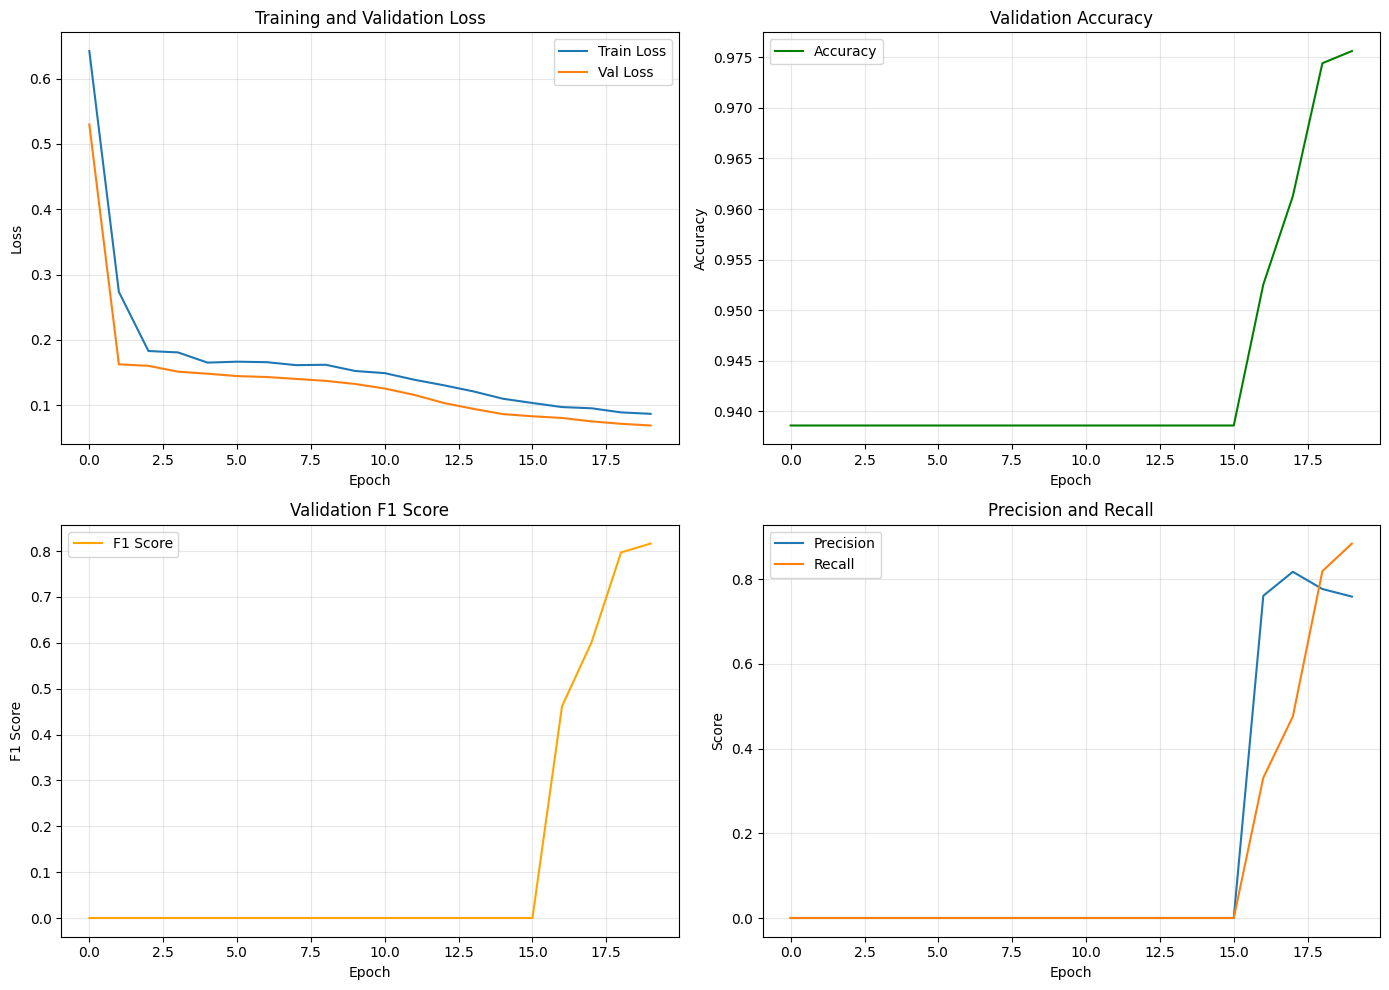


--- 3D Track Visualizations ---


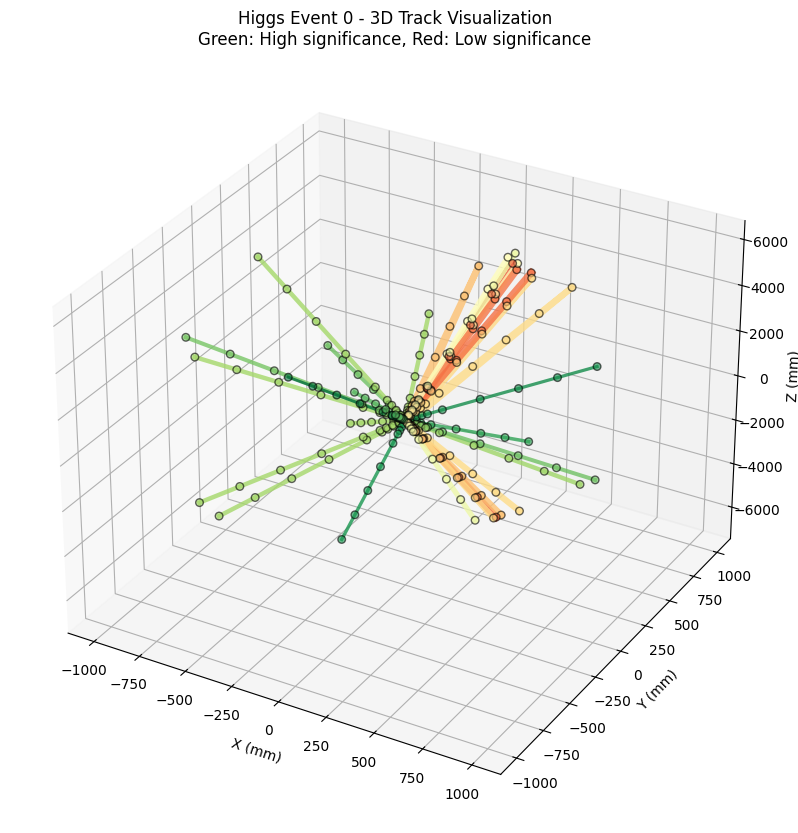

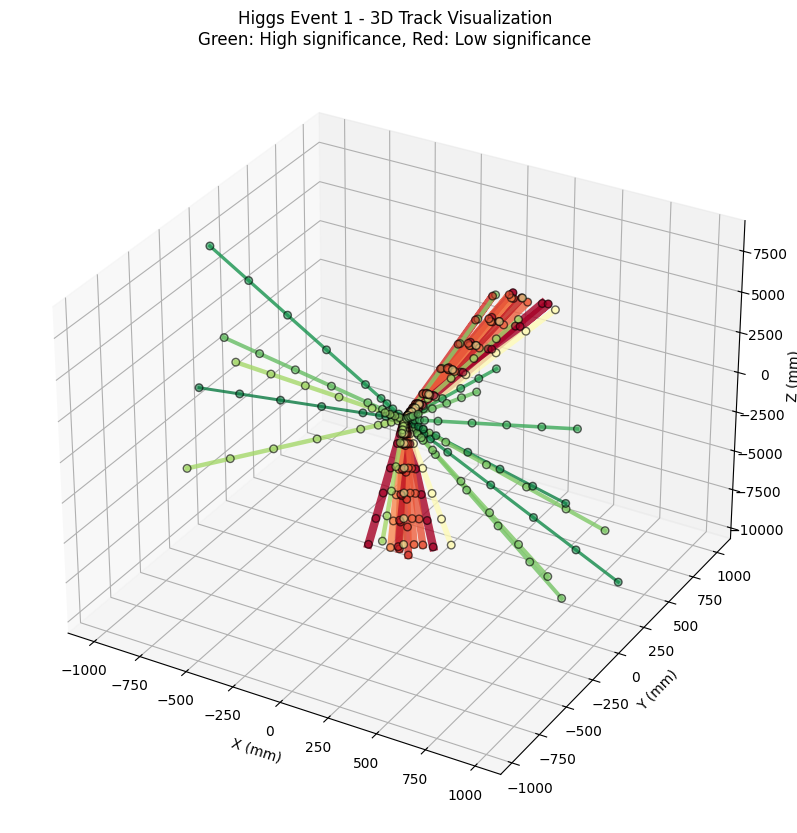

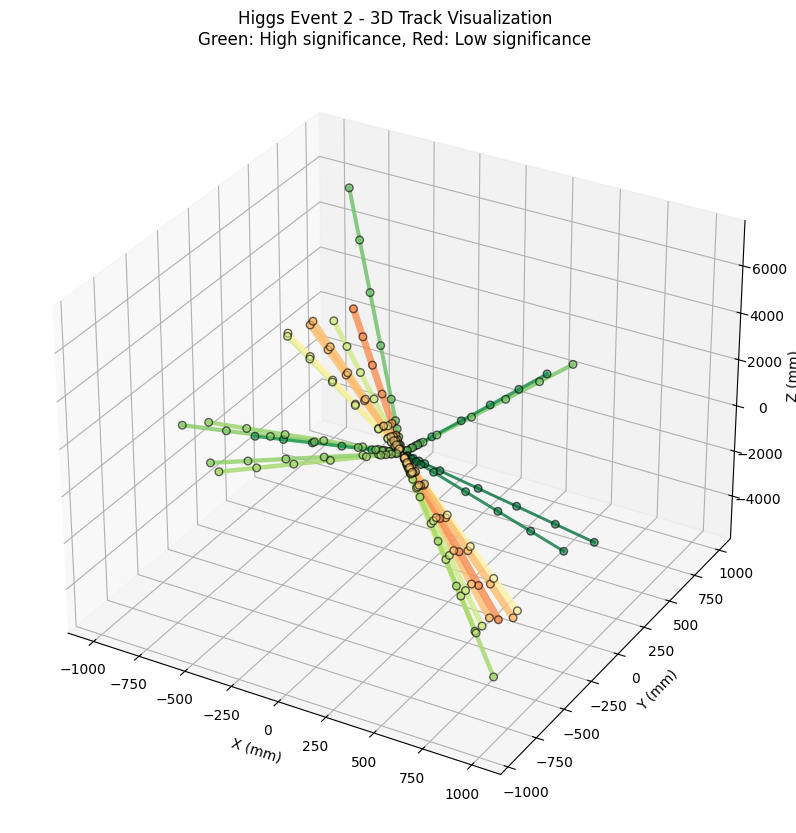


FINAL RESULTS

Quantum Model Results:
----------------------------------------
ACCURACY    : 0.9676
PRECISION   : 0.7051
RECALL      : 0.9040
F1_SCORE    : 0.7922
AUC_ROC     : 0.9824

✓ All results saved to: ./QuantumGNN_HiggsTracking


In [ ]:
if __name__ == "__main__":
    quantum_model, classical_model, quantum_metrics, classical_metrics = main()

In [ ]:
# Initialize the manager (this handles the /content/drive mount automatically)
drive_manager = GoogleDriveManager()

# Define your specific target path
target_path = "/content/drive/MyDrive/QuantumGNN_HiggsTracking/models"

# Ensure the folder exists
if not os.path.exists(target_path):
    os.makedirs(target_path)
    print(f"Created directory: {target_path}")

# Save the Quantum Model weights
# Using the standard torch.save for your specific path
q_model_path = os.path.join(target_path, "quantum_gnn_model.pth")
torch.save(quantum_model.state_dict(), q_model_path)


print(f"Successfully saved models to: {target_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Running in Google Colab - Drive mounted
✓ Project directories created at: /content/drive/MyDrive/Higgs_Track_Filter
Successfully saved models to: /content/drive/MyDrive/QuantumGNN_HiggsTracking/models
